<a href="https://colab.research.google.com/github/tasveebyousaf/pairs-trading-strategy/blob/main/Pairs_trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓  1257 trading days loaded.

  PERFORMANCE SUMMARY
  Initial Capital        $10,000
  Final Portfolio        $10,788.66
  Strategy Return        +7.89%
  MSFT Buy-and-Hold      +105.87%
  Annualised Sharpe      0.205
  Max Drawdown           -17.13%
  Total Trade Events     115

📊  Chart saved → pairs_trading_results.png


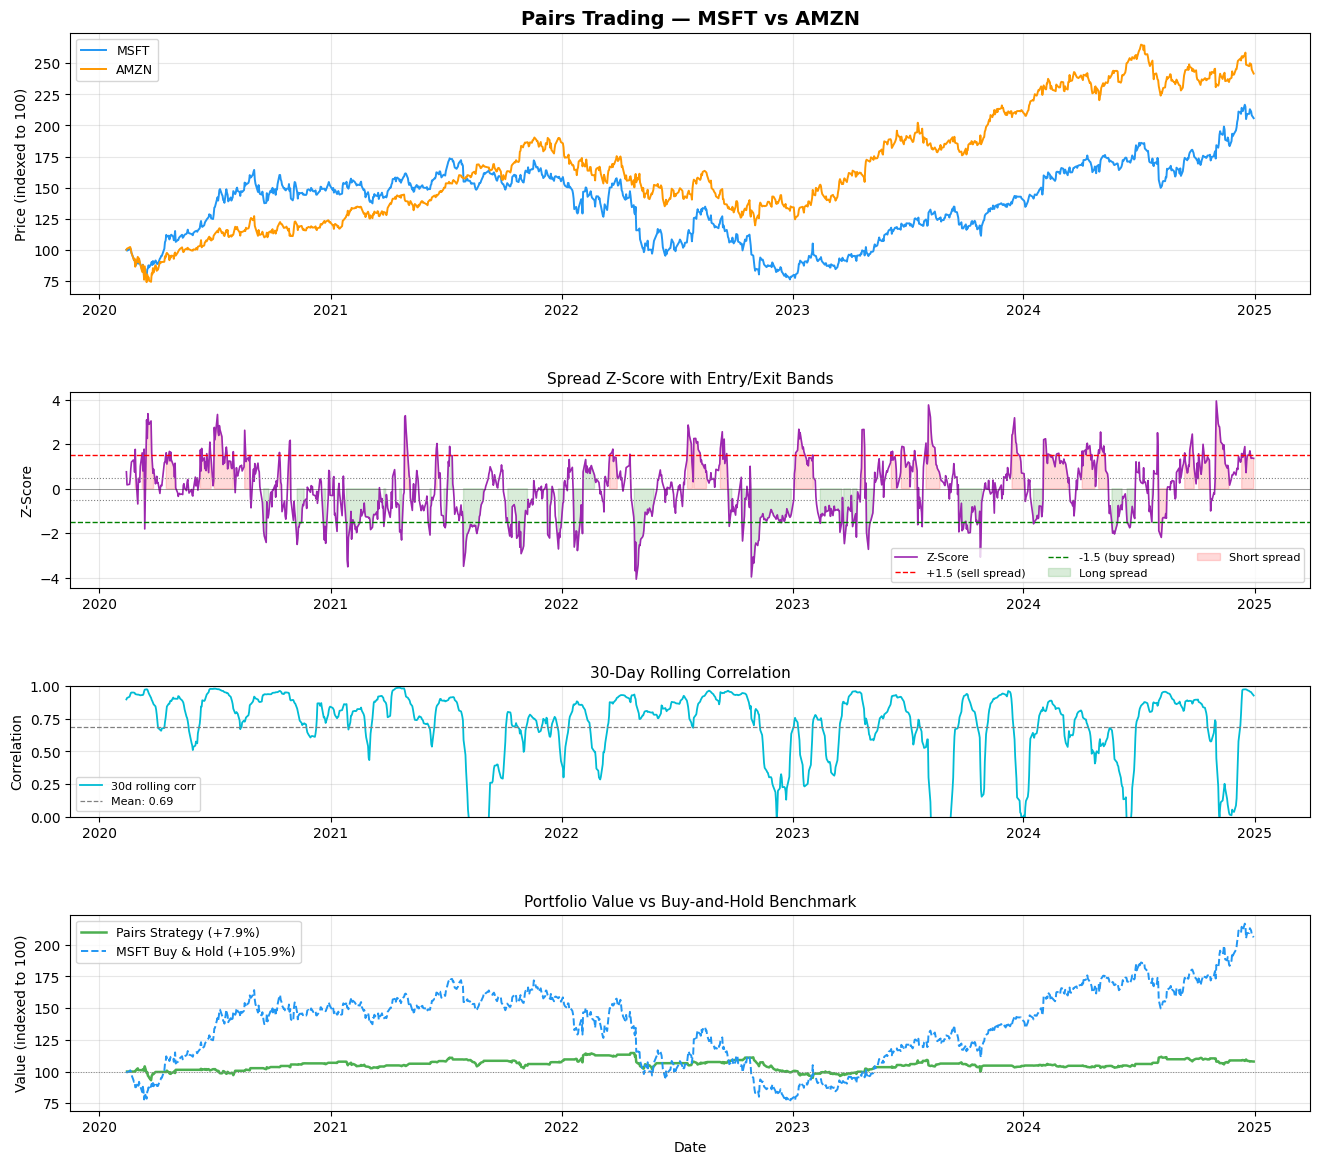

In [1]:
# ================================================================
#  Pairs Trading / Correlation Analysis Strategy
#  Stocks: MSFT & AMZN (S&P 500 tech pair)
#  Runnable in Google Colab or locally
# ================================================================

# ── 0. Install & imports ─────────────────────────────────────────
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

# ── 1. Settings ──────────────────────────────────────────────────
STOCK_A    = "MSFT"
STOCK_B    = "AMZN"
START      = "2020-01-01"
END        = "2024-12-31"

ROLL_WIN   = 30       # rolling window for correlation & z-score (days)
Z_ENTRY    = 1.5      # open a position when |z-score| exceeds this
Z_EXIT     = 0.5      # close a position when |z-score| falls below this
CAPITAL    = 10_000   # starting portfolio ($), split equally between legs
COMMISSION = 0.001    # 0.1% per trade

# ── 2. Download & align data ─────────────────────────────────────
print(f"Downloading {STOCK_A} and {STOCK_B} …")
raw = yf.download([STOCK_A, STOCK_B], start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
raw.columns = [STOCK_A, STOCK_B]
raw.dropna(inplace=True)
print(f"✓  {len(raw)} trading days loaded.\n")

# ── 3. Spread & z-score ──────────────────────────────────────────
# We trade the *log price spread* — more statistically stable than raw prices.
# Spread = log(MSFT) - log(AMZN)
df = pd.DataFrame(index=raw.index)
df[STOCK_A]   = raw[STOCK_A]
df[STOCK_B]   = raw[STOCK_B]
df["Spread"]  = np.log(raw[STOCK_A]) - np.log(raw[STOCK_B])

# Rolling mean & std of the spread → z-score
df["Roll_Mean"] = df["Spread"].rolling(ROLL_WIN).mean()
df["Roll_Std"]  = df["Spread"].rolling(ROLL_WIN).std()
df["Z_Score"]   = (df["Spread"] - df["Roll_Mean"]) / df["Roll_Std"]

# Rolling correlation (informational — shown in chart)
df["Roll_Corr"] = raw[STOCK_A].rolling(ROLL_WIN).corr(raw[STOCK_B])

df.dropna(inplace=True)

# ── 4. Signal generation ─────────────────────────────────────────
# z > +Z_ENTRY  →  spread too wide  →  SHORT A, LONG B  (signal = -1)
# z < -Z_ENTRY  →  spread too narrow → LONG A, SHORT B  (signal = +1)
# |z| < Z_EXIT  →  spread mean-reverted → close position (signal = 0)

df["Signal"] = 0
position = 0   # current position: +1, -1, or 0

signals = []
for z in df["Z_Score"]:
    if position == 0:
        if z > Z_ENTRY:
            position = -1   # short the spread
        elif z < -Z_ENTRY:
            position = 1    # long the spread
    elif position != 0:
        if abs(z) < Z_EXIT:
            position = 0    # exit
    signals.append(position)

df["Signal"] = signals
df["Trade"]  = df["Signal"].diff().fillna(0)   # non-zero = trade event

# ── 5. Backtest ───────────────────────────────────────────────────
# Each day's P&L = position * daily change in spread
# We size each leg at CAPITAL / 2

half_capital  = CAPITAL / 2
df["Spread_Return"] = df["Spread"].diff()                 # daily spread change
df["Strategy_PnL"]  = df["Signal"].shift(1) * df["Spread_Return"] * half_capital

# Deduct commission on every trade event (entry + exit)
trade_days = df["Trade"] != 0
df.loc[trade_days, "Strategy_PnL"] -= CAPITAL * COMMISSION

df["Cumulative_PnL"]  = df["Strategy_PnL"].cumsum()
df["Portfolio_Value"] = CAPITAL + df["Cumulative_PnL"]

# ── 6. Performance metrics ────────────────────────────────────────
final_value  = df["Portfolio_Value"].iloc[-1]
total_return = (final_value - CAPITAL) / CAPITAL * 100

daily_ret = df["Strategy_PnL"] / df["Portfolio_Value"].shift(1)
daily_ret.replace([np.inf, -np.inf], np.nan, inplace=True)
sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(252)

roll_max   = df["Portfolio_Value"].cummax()
drawdown   = (df["Portfolio_Value"] - roll_max) / roll_max
max_dd     = drawdown.min() * 100
n_trades   = int(trade_days.sum())

# Buy-and-hold MSFT benchmark
bah_return = (df[STOCK_A].iloc[-1] - df[STOCK_A].iloc[0]) / df[STOCK_A].iloc[0] * 100

print("=" * 42)
print("  PERFORMANCE SUMMARY")
print("=" * 42)
print(f"  {'Initial Capital':<22} ${CAPITAL:,.0f}")
print(f"  {'Final Portfolio':<22} ${final_value:,.2f}")
print(f"  {'Strategy Return':<22} {total_return:+.2f}%")
print(f"  {'MSFT Buy-and-Hold':<22} {bah_return:+.2f}%")
print(f"  {'Annualised Sharpe':<22} {sharpe:.3f}")
print(f"  {'Max Drawdown':<22} {max_dd:.2f}%")
print(f"  {'Total Trade Events':<22} {n_trades}")
print("=" * 42)

# ── 7. Plot ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(4, 1, hspace=0.50, height_ratios=[2, 1.5, 1, 1.5])

# ── Panel 1: Normalised prices ─────────────────────────────────
ax1 = fig.add_subplot(gs[0])
norm_a = df[STOCK_A] / df[STOCK_A].iloc[0] * 100
norm_b = df[STOCK_B] / df[STOCK_B].iloc[0] * 100
ax1.plot(df.index, norm_a, label=STOCK_A, color="#2196F3", lw=1.4)
ax1.plot(df.index, norm_b, label=STOCK_B, color="#FF9800", lw=1.4)
ax1.set_title(f"Pairs Trading — {STOCK_A} vs {STOCK_B}", fontsize=14, fontweight="bold")
ax1.set_ylabel("Price (indexed to 100)")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── Panel 2: Spread & z-score with entry/exit bands ────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(df.index, df["Z_Score"], color="#9C27B0", lw=1.2, label="Z-Score")
ax2.axhline( Z_ENTRY, color="red",   ls="--", lw=1, label=f"+{Z_ENTRY} (sell spread)")
ax2.axhline(-Z_ENTRY, color="green", ls="--", lw=1, label=f"-{Z_ENTRY} (buy spread)")
ax2.axhline( Z_EXIT,  color="grey",  ls=":",  lw=0.8)
ax2.axhline(-Z_EXIT,  color="grey",  ls=":",  lw=0.8)
ax2.axhline(0,        color="black", ls="-",  lw=0.6, alpha=0.4)

# shade active positions
ax2.fill_between(df.index, df["Z_Score"], 0,
                 where=(df["Signal"] == 1),  alpha=0.15, color="green", label="Long spread")
ax2.fill_between(df.index, df["Z_Score"], 0,
                 where=(df["Signal"] == -1), alpha=0.15, color="red",   label="Short spread")
ax2.set_ylabel("Z-Score")
ax2.set_title("Spread Z-Score with Entry/Exit Bands", fontsize=11)
ax2.legend(fontsize=8, ncol=3); ax2.grid(alpha=0.3)

# ── Panel 3: Rolling correlation ────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(df.index, df["Roll_Corr"], color="#00BCD4", lw=1.3, label=f"{ROLL_WIN}d rolling corr")
ax3.axhline(df["Roll_Corr"].mean(), color="grey", ls="--", lw=0.9,
            label=f"Mean: {df['Roll_Corr'].mean():.2f}")
ax3.set_ylabel("Correlation")
ax3.set_title(f"{ROLL_WIN}-Day Rolling Correlation", fontsize=11)
ax3.set_ylim(0, 1); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# ── Panel 4: Portfolio vs buy-and-hold ─────────────────────────
ax4 = fig.add_subplot(gs[3])
bah_indexed  = df[STOCK_A] / df[STOCK_A].iloc[0] * 100
port_indexed = df["Portfolio_Value"] / CAPITAL * 100
ax4.plot(df.index, port_indexed, color="#4CAF50", lw=1.8,
         label=f"Pairs Strategy ({total_return:+.1f}%)")
ax4.plot(df.index, bah_indexed,  color="#2196F3", lw=1.4, ls="--",
         label=f"{STOCK_A} Buy & Hold ({bah_return:+.1f}%)")
ax4.axhline(100, color="grey", lw=0.7, ls=":")
ax4.set_ylabel("Value (indexed to 100)")
ax4.set_xlabel("Date")
ax4.set_title("Portfolio Value vs Buy-and-Hold Benchmark", fontsize=11)
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

plt.savefig("pairs_trading_results.png", dpi=150, bbox_inches="tight")
print("\n📊  Chart saved → pairs_trading_results.png")
plt.show()